# FFN 실습


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 재현성 고정
np.random.seed(42)
torch.manual_seed(42)
plt.rcParams["figure.dpi"] = 120

print("NumPy version  :", np.__version__)
print("PyTorch version:", torch.__version__)


NumPy version  : 2.3.4
PyTorch version: 2.9.0


## 1. Activation Function

activation function은 선형 변환 뒤에 비선형성을 추가해 더 복잡한 패턴을 표현하게 해줍니다.
여기서는 `Sigmoid`, `Tanh`, `ReLU`를 비교합니다.


input   : [-2.  -0.5  0.   0.5  2. ]
sigmoid : [0.1192 0.3775 0.5    0.6225 0.8808]
tanh    : [-0.964  -0.4621  0.      0.4621  0.964 ]
relu    : [0.  0.  0.  0.5 2. ]


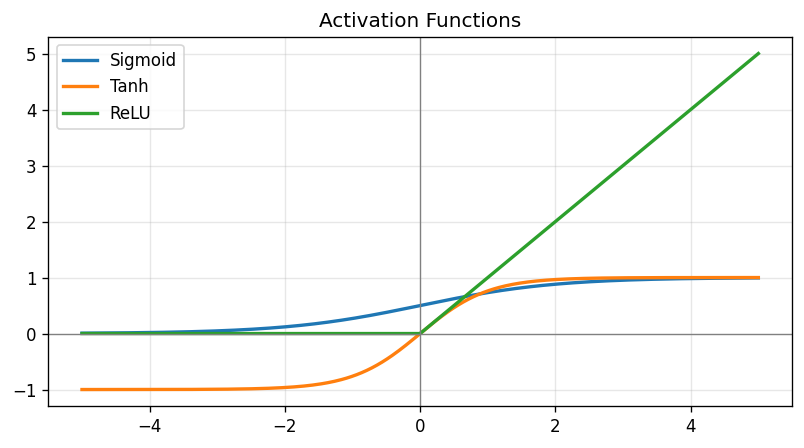

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)


def relu(x):
    return np.maximum(0, x)


values = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
print("input   :", values)
print("sigmoid :", np.round(sigmoid(values), 4))
print("tanh    :", np.round(tanh(values), 4))
print("relu    :", np.round(relu(values), 4))

x = np.linspace(-5, 5, 400)
plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid(x), label="Sigmoid", linewidth=2)
plt.plot(x, tanh(x), label="Tanh", linewidth=2)
plt.plot(x, relu(x), label="ReLU", linewidth=2)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Activation Functions")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 2. `nn.Linear`가 하는 일

`nn.Linear(in_features, out_features)`는 입력 벡터를 다른 차원의 벡터로 바꾸는 선형층입니다.
입력 shape와 출력 shape를 직접 확인해봅니다.


In [3]:
linear = nn.Linear(3, 4)

example_x = torch.tensor(
    [[0.2, 0.7, 1.0],
     [1.2, -0.3, 0.5]],
    dtype=torch.float32,
)
example_out = linear(example_x)

print("input shape :", tuple(example_x.shape))
print("weight shape:", tuple(linear.weight.shape))
print("bias shape  :", tuple(linear.bias.shape))
print("output shape:", tuple(example_out.shape))
print(example_out)


input shape : (2, 3)
weight shape: (4, 3)
bias shape  : (4,)
output shape: (2, 4)
tensor([[ 0.7150,  0.2122,  0.9685,  0.2931],
        [ 0.7448,  0.8108,  0.0938, -0.6863]], grad_fn=<AddmmBackward0>)


## 3. 기본 DNN(MLP) 만들기

이미지를 펼친 뒤 hidden layer를 거쳐 10개 클래스 점수를 출력하는 가장 기본적인 구조입니다.


In [4]:
class BasicDNN(nn.Module):
    def __init__(self, input_dim=28 * 28, hidden_dim=128, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x


model = BasicDNN()
print(model)


BasicDNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4. MNIST 데이터셋 불러오기

MNIST는 28x28 흑백 손글씨 숫자 이미지 데이터셋입니다.
배치 하나를 불러와 shape와 이미지를 확인합니다.


images shape: (8, 1, 28, 28)
labels      : [4, 7, 3, 0, 2, 1, 4, 0]


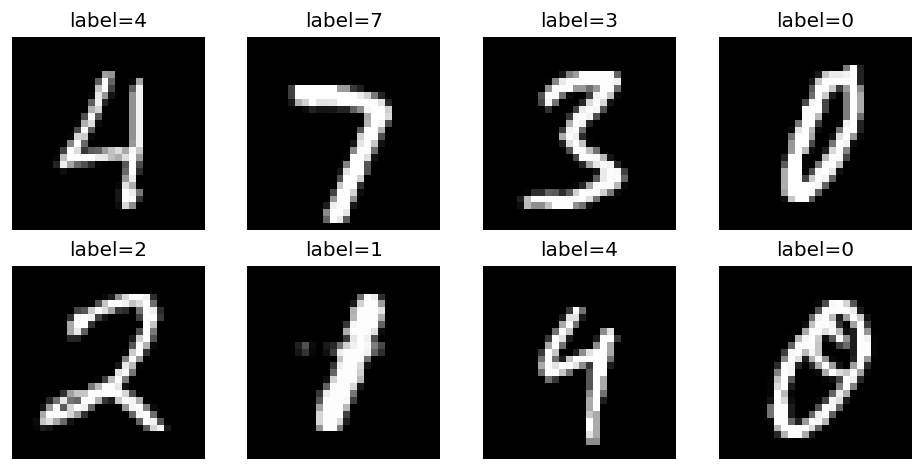

In [5]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# 배치 하나 확인
images, labels = next(iter(train_loader))
print("images shape:", tuple(images.shape))
print("labels      :", labels.tolist())

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i, 0], cmap="gray")
    ax.set_title(f"label={labels[i].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Forward Pass 해보기

아직 학습 전 모델이라 예측이 정확하지 않을 수 있습니다.
하지만 `logit -> probability -> prediction` 흐름은 바로 확인할 수 있습니다.


In [6]:
with torch.no_grad():
    logits = model(images)
    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)

print("logits shape :", tuple(logits.shape))
print("predictions  :", preds.tolist())
print("true labels  :", labels.tolist())
print()
print("first sample probability vector:")
print(torch.round(probs[0] * 1000) / 1000)


logits shape : (8, 10)
predictions  : [3, 3, 3, 3, 1, 7, 1, 3]
true labels  : [4, 7, 3, 0, 2, 1, 4, 0]

first sample probability vector:
tensor([0.0980, 0.1050, 0.0990, 0.1120, 0.0890, 0.0950, 0.0910, 0.1060, 0.0930,
        0.1110])


## 6. Hidden Dimension 바꿔보기

hidden layer 크기는 대표적인 하이퍼파라미터입니다.
hidden size가 달라도 출력 shape는 `(batch_size, 10)`으로 유지됩니다.


In [7]:
for hidden_dim in [32, 64, 128, 256]:
    temp_model = BasicDNN(hidden_dim=hidden_dim)
    with torch.no_grad():
        temp_logits = temp_model(images)
    print(f"hidden_dim={hidden_dim:3d} -> output shape={tuple(temp_logits.shape)}")


hidden_dim= 32 -> output shape=(8, 10)
hidden_dim= 64 -> output shape=(8, 10)
hidden_dim=128 -> output shape=(8, 10)
hidden_dim=256 -> output shape=(8, 10)


## 7. FashionMNIST에도 적용하기

FashionMNIST도 이미지 크기와 클래스 수가 같아서 같은 구조를 거의 그대로 사용할 수 있습니다.


In [8]:
fashion_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)
fashion_loader = DataLoader(fashion_dataset, batch_size=8, shuffle=True)
fashion_images, fashion_labels = next(iter(fashion_loader))

with torch.no_grad():
    fashion_logits = model(fashion_images)
    fashion_preds = fashion_logits.argmax(dim=1)

print("fashion batch shape:", tuple(fashion_images.shape))
print("fashion labels     :", fashion_labels.tolist())
print("fashion preds      :", fashion_preds.tolist())


fashion batch shape: (8, 1, 28, 28)
fashion labels     : [4, 8, 2, 4, 0, 8, 5, 6]
fashion preds      : [3, 3, 3, 3, 1, 3, 3, 3]


## 8. 연습 문제

1. `ReLU`, `Sigmoid`, `Tanh` 중 하나를 골라 출력 범위와 특징을 설명해보세요.
2. `BasicDNN(hidden_dim=64)`와 `BasicDNN(hidden_dim=256)`의 차이를 비교해보세요.
3. `self.act = nn.ReLU()`를 `nn.Sigmoid()` 또는 `nn.Tanh()`로 바꿔 forward pass를 다시 확인해보세요.
4. hidden layer를 하나 더 추가한 `DeeperDNN`을 직접 만들어보세요.


## 9. 연습문제 풀이

1. `ReLU`는 음수를 0으로 만들고 양수는 그대로 둡니다. 출력 범위는 `[0, \infty)`라서 계산이 단순하고 많이 쓰입니다.
2. `hidden_dim=256`은 `64`보다 중간 표현 차원이 커서 파라미터 수가 더 많습니다. 출력 shape는 둘 다 `(batch_size, 10)`으로 같습니다.
3. activation만 바꿔도 같은 입력에 대한 logit 분포가 달라집니다. 아래 셀에서 `ReLU`, `Sigmoid`, `Tanh`를 직접 비교합니다.
4. hidden layer를 하나 더 넣은 `DeeperDNN`도 같은 방식으로 forward pass를 할 수 있습니다.


In [9]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())


print("[Exercise 2] hidden_dim 비교")
for hidden_dim in [64, 256]:
    temp_model = BasicDNN(hidden_dim=hidden_dim)
    with torch.no_grad():
        temp_logits = temp_model(images)
    print(
        f"hidden_dim={hidden_dim:3d} | output_shape={tuple(temp_logits.shape)} | params={count_params(temp_model):,}"
    )


class ActivationDNN(nn.Module):
    def __init__(self, activation, hidden_dim=128):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden_dim)
        self.act = activation
        self.fc2 = nn.Linear(hidden_dim, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x


print("\n[Exercise 3] activation 비교")
activations = {
    "ReLU": nn.ReLU(),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
}

for name, activation in activations.items():
    temp_model = ActivationDNN(activation)
    with torch.no_grad():
        temp_logits = temp_model(images)
    print(
        f"{name:8s} | mean={temp_logits.mean().item():.4f} | std={temp_logits.std().item():.4f} | first_pred={temp_logits.argmax(dim=1)[0].item()}"
    )


[Exercise 2] hidden_dim 비교
hidden_dim= 64 | output_shape=(8, 10) | params=50,890
hidden_dim=256 | output_shape=(8, 10) | params=203,530

[Exercise 3] activation 비교
ReLU     | mean=0.0438 | std=0.0732 | first_pred=1
Sigmoid  | mean=-0.0938 | std=0.3376 | first_pred=5
Tanh     | mean=0.0274 | std=0.0810 | first_pred=8


In [10]:
class DeeperDNN(nn.Module):
    def __init__(self, input_dim=28 * 28, hidden1=128, hidden2=64, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return x


deeper_model = DeeperDNN()
with torch.no_grad():
    mnist_logits = deeper_model(images)
    fashion_logits = deeper_model(fashion_images)

print("[Exercise 4] DeeperDNN 확인")
print("MNIST output shape       :", tuple(mnist_logits.shape))
print("FashionMNIST output shape:", tuple(fashion_logits.shape))
print("DeeperDNN params         :", f"{count_params(deeper_model):,}")
print("MNIST preds             :", mnist_logits.argmax(dim=1).tolist())


[Exercise 4] DeeperDNN 확인
MNIST output shape       : (8, 10)
FashionMNIST output shape: (8, 10)
DeeperDNN params         : 109,386
MNIST preds             : [4, 8, 4, 7, 4, 8, 8, 8]
